In [42]:
# from pathlib import Path
# import pandas as pd

# user_anime_df = pd.read_csv("../data/UserAnimeList.csv")

Data Cleaning & Memory Optimization for user_anime_df

In [43]:
# user_anime_df['my_score'] = user_anime_df['my_score'].astype('int8')
# user_anime_df['my_status'] = user_anime_df['my_status'].astype('int8')
# user_anime_df['anime_id'] = pd.to_numeric(user_anime_df['anime_id'], downcast='integer')
# user_anime_df.shape

In [44]:
# user_anime_df_completed = user_anime_df[user_anime_df['my_status'] == 2]
# user_anime_df_filtered = user_anime_df_completed[["username", "anime_id", "my_score"]]
# user_anime_df_filtered.shape

In [45]:
# display(sum(user_anime_df_filtered["my_score"].isna()))
# display(sum(user_anime_df_filtered["anime_id"].isna()))
# display(sum(user_anime_df_filtered["username"].isna()))

In [46]:
# user_anime_df_filtered.dropna(inplace=True)
# display(sum(user_anime_df["username"].isna()))

In [47]:
# user_anime_df_filtered.to_parquet("../data/user_anime_df.parquet", engine="pyarrow", compression="snappy")

Read in Processed Data

In [49]:
import pandas as pd
user_anime_df = pd.read_parquet("../data/user_anime_df.parquet", engine="pyarrow")
user_df = pd.read_csv("../data/UserList.csv")

Data preprocessing

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScalar

snapshot_year = 2018 # when the dataset was created
birth_years = pd.to_numeric(user_df['birth_date'].astype(str).str[:4], errors='coerce')
join_years = pd.to_numeric(user_df['join_date'].astype(str).str[:4], errors='coerce')

calculated_age = snapshot_year - birth_years
calculated_duration = snapshot_year - join_years
invalid_birth = (birth_years > join_years) | (birth_years > snapshot_year)
user_df['age'] = np.where(invalid_birth, np.nan, calculated_age)
user_df['duration'] = np.where(join_years > 2018, np.nan, calculated_duration)

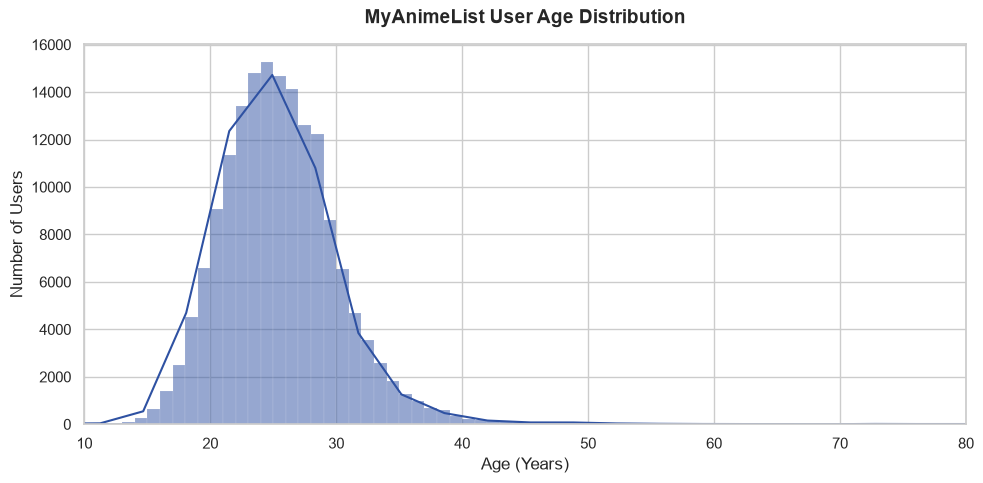

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style and MAL-inspired brand color
sns.set_theme(style="whitegrid")
mal_blue = "#2e51a2" 

# Create the figure
plt.figure(figsize=(10, 5), dpi=100)

# Plot histogram with a Kernel Density Estimate (KDE) line
sns.histplot(
    data=user_df, 
    x='age', 
    bins=int(user_df['age'].max() - user_df['age'].min()), 
    kde=True, 
    color=mal_blue,
    edgecolor='white'
)

# Labeling and styling
plt.title('MyAnimeList User Age Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.xlim(10, 80)  # Limits to reasonable age ranges to focus on the core user base

# Clean up layout and display
plt.tight_layout()
plt.show()


Before removing over 60 (Mean: 25.4, Median: 25, Std: 7.2)

After  removing over 60 (Mean: 25.1, Median: 25, Std: 4.7)

In [52]:
# Convert any age over 60 to NaN
user_df['age'] = np.where((user_df['age'] > 60) | (user_df['age'] < 10), np.nan, user_df['age'])

# Print updated metrics to verify
print("New Cleaned Mean:", user_df['age'].mean())
print("New Cleaned Median:", user_df['age'].median())
print("New Cleaned Std:", user_df['age'].std())

New Cleaned Mean: 25.08568961278058
New Cleaned Median: 25.0
New Cleaned Std: 4.710531887385849


In [53]:
# Bin users into meaningful lifestyle categories
age_bins = [0, 17, 24, 34, 60]
age_labels = ['Teens (<18)', 'College/Young Adult (18-24)', 'Working Adult (25-34)', 'Older Fan (35+)']

user_df['age_group'] = pd.cut(user_df['age'], bins=age_bins, labels=age_labels, right=False)
user_df = pd.get_dummies(user_df, columns=['age_group'], dummy_na=True, dtype='int8')
user_df = pd.get_dummies(user_df, columns=['gender'], dummy_na=True, dtype='int8')

user_df.drop(columns=['birth_date', 'user_id', 'access_rank', 'join_date' ,'last_online'], inplace=True)
user_df

,username,user_watching,user_completed,user_onhold,user_dropped,user_plantowatch,user_days_spent_watching,location,stats_mean_score,stats_rewatched,...,duration,age_group_Teens (<18),age_group_College/Young Adult (18-24),age_group_Working Adult (25-34),age_group_Older Fan (35+),age_group_nan,gender_Female,gender_Male,gender_Non-Binary,gender_nan
0,karthiga,3,49,1,0,0,55.31,"Chennai, India",7.43,0.0,...,5.0,0,0,1,0,0,1,0,0,0
1,RedvelvetDaisuki,61,396,39,0,206,118.07,Manila,6.78,80.0,...,6.0,0,1,0,0,0,1,0,0,0
2,Damonashu,45,195,27,25,59,83.70,"Detroit,Michigan",6.15,6.0,...,10.0,0,0,1,0,0,0,1,0,0
3,bskai,25,414,2,5,11,167.16,"Nayarit, Mexico",8.27,1.0,...,9.0,0,0,1,0,0,0,1,0,0
4,shuzzable,36,72,16,2,25,35.48,NaN,9.06,7.0,...,5.0,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302670,ScruffyPuffy,0,27,0,0,0,7.92,NaN,0.00,0.0,...,5.0,0,0,0,0,1,0,0,0,1
302671,Torasori,22,239,0,4,176,86.88,"Latvia, Riga",8.98,47.0,...,4.0,0,1,0,0,0,0,1,0,0
302672,onpc,5,169,2,5,24,38.36,NaN,7.72,0.0,...,6.0,0,0,0,0,1,0,1,0,0
302673,HMicca,11,73,2,2,16,119.97,"Birmingham, England",8.89,11.0,...,6.0,0,1,0,0,0,1,0,0,0


In [85]:
user_df = user_df[user_df['user_completed'] != 0]

In [111]:
user_df_clean = user_df
behavioral_cols = ['user_completed', 'user_watching', 'user_onhold', 'user_plantowatch', 'user_dropped', 'user_days_spent_watching']

for col in behavioral_cols:
    cutoff = user_df_clean[col].quantile(0.999)
    user_df_clean = user_df_clean[user_df_clean[col] < cutoff]
    print(f"Filtered {col} at 99.9% cutoff value: {int(cutoff)}")

print(f"Final clean dataset shape: {user_df_clean.shape}")

Filtered user_completed at 99.9% cutoff value: 2279
Filtered user_watching at 99.9% cutoff value: 366
Filtered user_onhold at 99.9% cutoff value: 297
Filtered user_plantowatch at 99.9% cutoff value: 1668
Filtered user_dropped at 99.9% cutoff value: 315
Filtered user_days_spent_watching at 99.9% cutoff value: 701
Final clean dataset shape: (275604, 22)


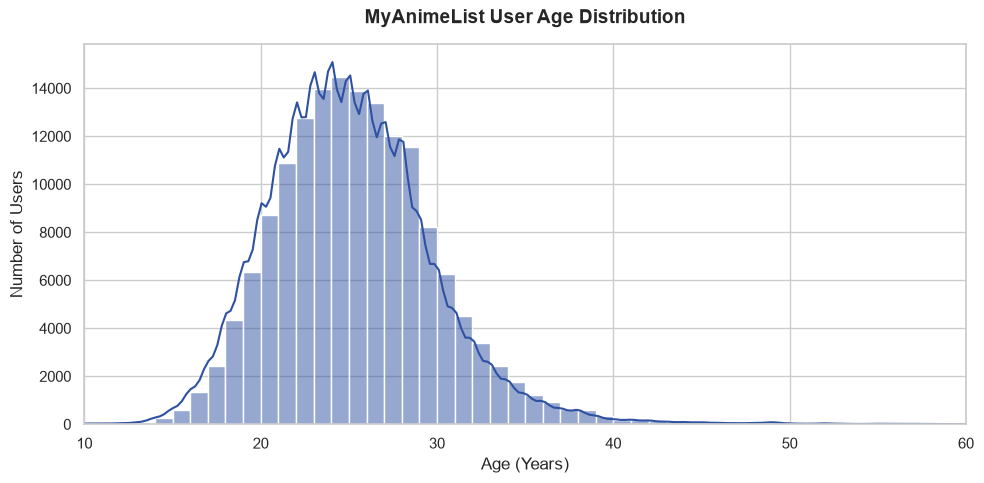

In [116]:
# Set the style and MAL-inspired brand color
sns.set_theme(style="whitegrid")
mal_blue = "#2e51a2" 

# Create the figure
plt.figure(figsize=(10, 5), dpi=100)

# Plot histogram with a Kernel Density Estimate (KDE) line
sns.histplot(
    data=user_df_clean, 
    x='age', 
    bins=int(user_df_clean['age'].max() - user_df_clean['age'].min()), 
    kde=True, 
    color=mal_blue,
    edgecolor='white'
)

# Labeling and styling
plt.title('MyAnimeList User Age Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.xlim(user_df['age'].min(), 60)  # Limits to reasonable age ranges to focus on the core user base

# Clean up layout and display
plt.tight_layout()
plt.show()


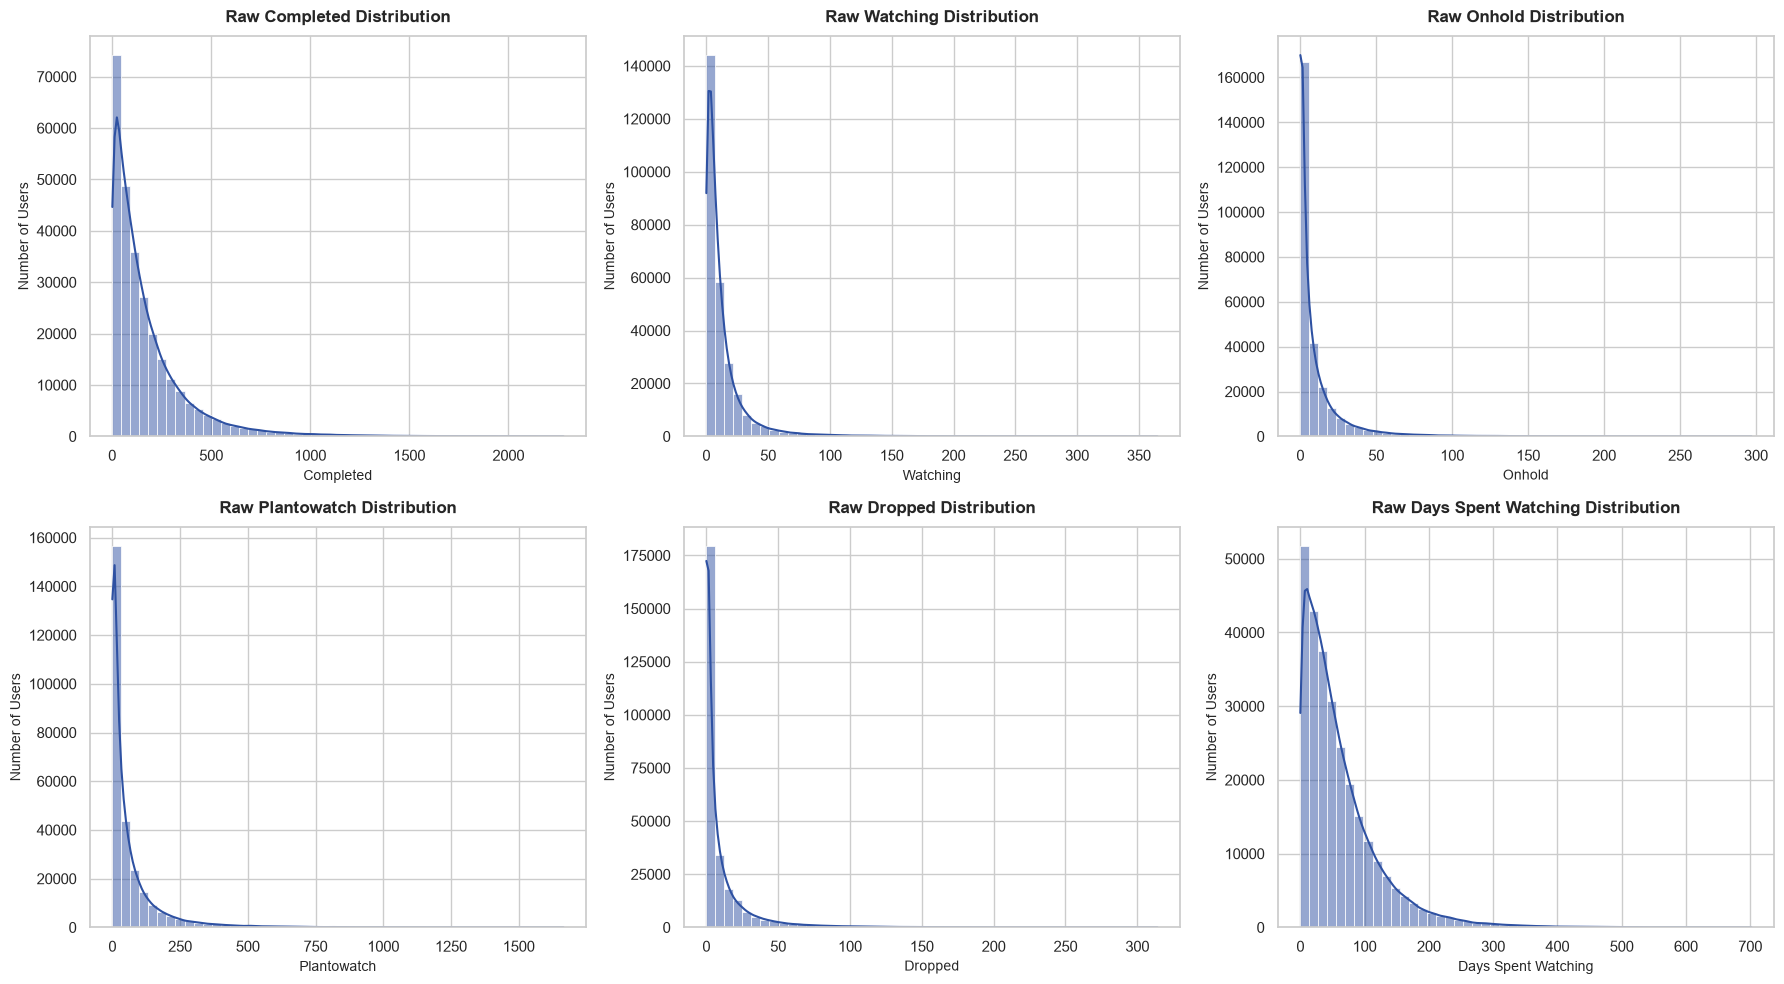

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style and MAL-inspired brand color
sns.set_theme(style="whitegrid")
mal_blue = "#2e51a2"

behavioral_cols = [
    'user_completed', 'user_watching', 'user_onhold', 
    'user_plantowatch', 'user_dropped', 'user_days_spent_watching'
]

# Create a 2x3 grid for the 6 metrics
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10), dpi=100)
axes = axes.flatten()

# Loop through and plot the completely raw data
for i, col in enumerate(behavioral_cols):
    sns.histplot(
        data=user_df_clean,
        x=col,
        bins=50,                  # Safely chunks raw data without crashing memory
        kde=True,
        color=mal_blue,
        edgecolor='white',
        ax=axes[i]
    )
    
    # Clean formatting for raw titles
    clean_title = col.replace('user_', '').replace('_', ' ').title()
    axes[i].set_title(f'Raw {clean_title} Distribution', fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlabel(clean_title, fontsize=10)
    axes[i].set_ylabel('Number of Users', fontsize=10)

plt.tight_layout()
plt.show()


In [117]:
user_df_clean.columns

Index(['username', 'user_watching', 'user_completed', 'user_onhold',
       'user_dropped', 'user_plantowatch', 'user_days_spent_watching',
       'location', 'stats_mean_score', 'stats_rewatched', 'stats_episodes',
       'age', 'duration', 'age_group_Teens (<18)',
       'age_group_College/Young Adult (18-24)',
       'age_group_Working Adult (25-34)', 'age_group_Older Fan (35+)',
       'age_group_nan', 'gender_Female', 'gender_Male', 'gender_Non-Binary',
       'gender_nan'],
      dtype='str')

In [ ]:
user_df_clean['log_completed'] = np.log1p(user_df_clean['user_completed'])
scalar = StandardScalar()
user_df_clean['scaled_completed'] = np.fit_transform(user_df_clean)